In [1]:
import os
import json
import shutil
import random
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings('ignore')

In [2]:
print(f"TensorFlow version : {tf.__version__}")
print(f"GPU Available      : {tf.config.list_physical_devices('GPU')}")

TensorFlow version : 2.16.2
GPU Available      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# **DATA LOADER**

In [4]:
RAW_DATA_DIR = Path('../../data/raw/garbage_classification')

print("Folder yang ditemukan:")
for class_folder in sorted(RAW_DATA_DIR.iterdir()):
    if class_folder.is_dir():
        image_count = len(list(class_folder.glob('*')))
        print(f"  {class_folder.name:15} | {image_count} gambar")

Folder yang ditemukan:
  battery         | 945 gambar
  biological      | 985 gambar
  brown-glass     | 607 gambar
  cardboard       | 891 gambar
  clothes         | 5325 gambar
  green-glass     | 629 gambar
  metal           | 769 gambar
  paper           | 1050 gambar
  plastic         | 865 gambar
  shoes           | 1977 gambar
  trash           | 697 gambar
  white-glass     | 775 gambar


Kelas (12): ['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']


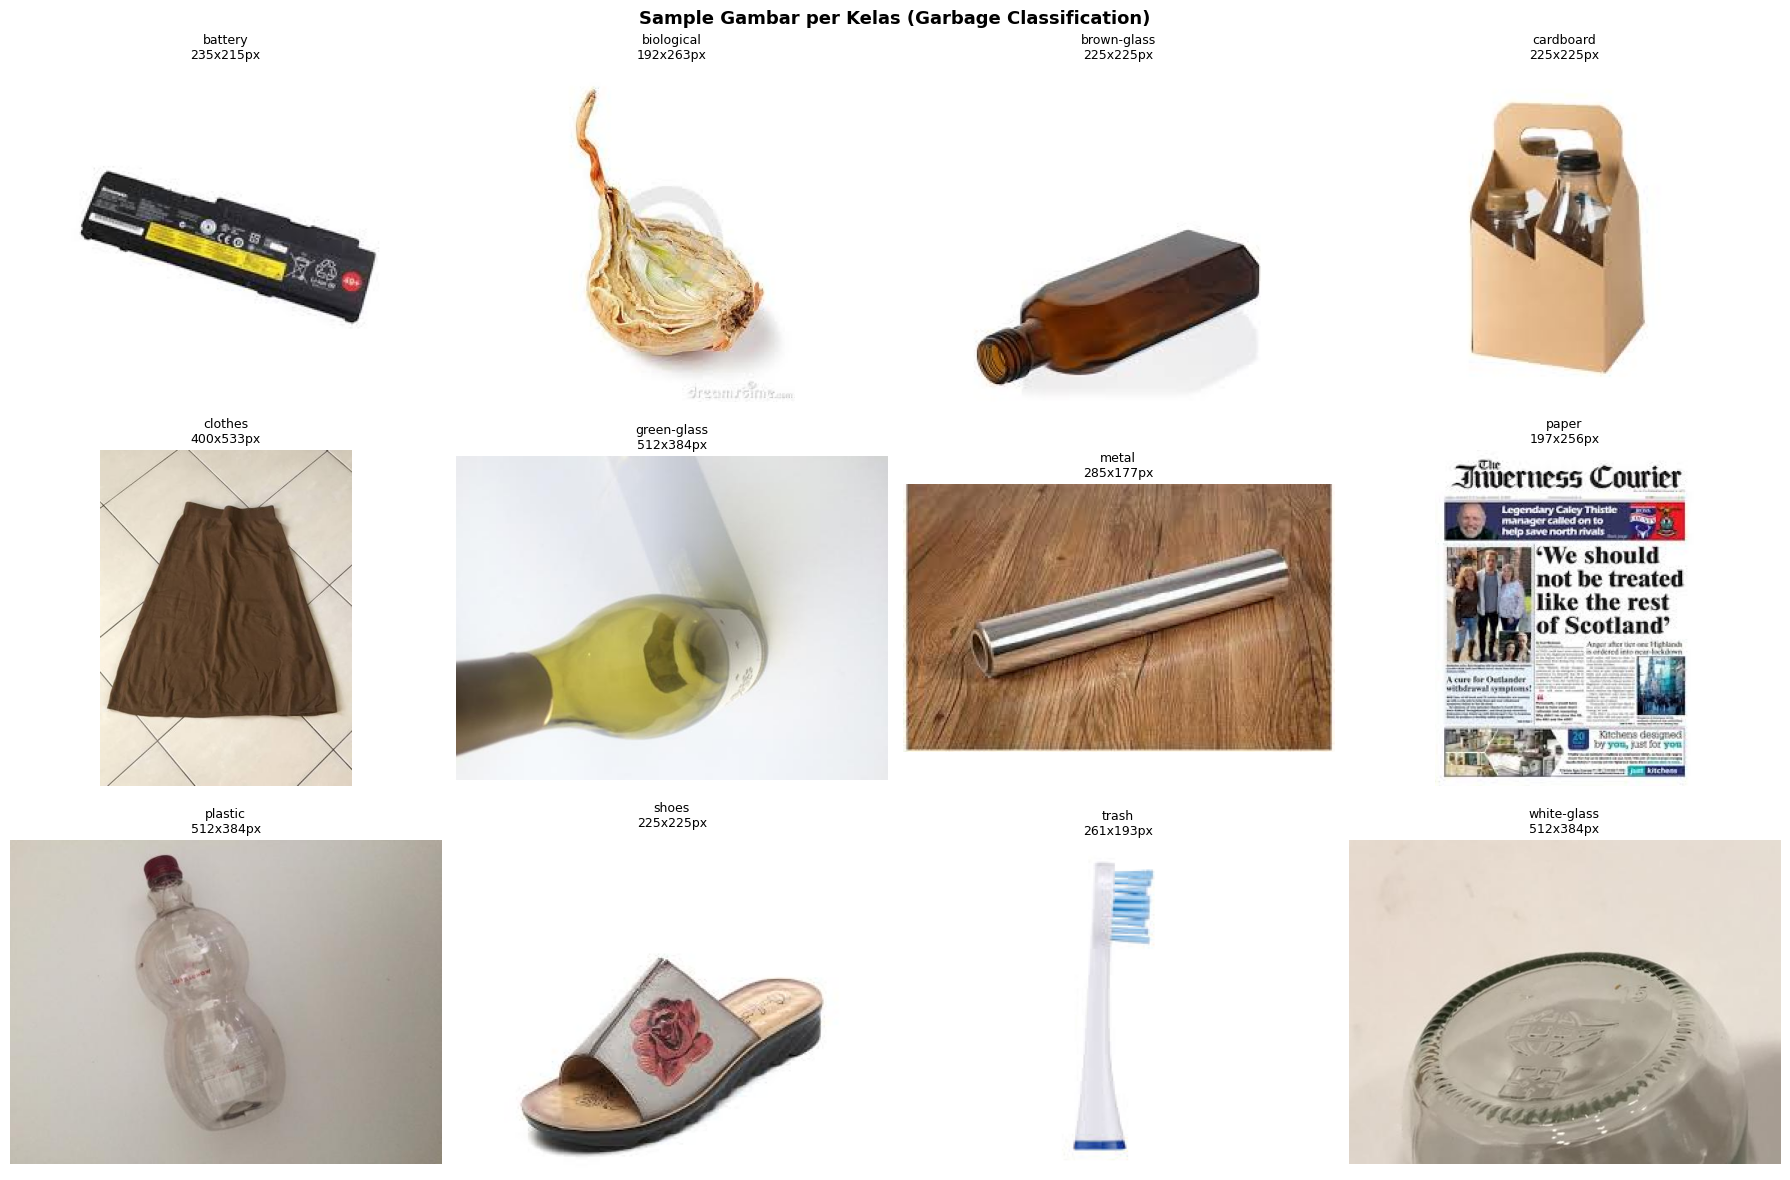

In [5]:
CLASS_NAMES = sorted([d.name for d in RAW_DATA_DIR.iterdir() if d.is_dir()])
NUM_CLASSES = len(CLASS_NAMES)
print(f"Kelas ({NUM_CLASSES}): {CLASS_NAMES}")

cols = 4
rows = (NUM_CLASSES + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4))
axes = axes.flatten()

for idx, class_name in enumerate(CLASS_NAMES):
    class_folder = RAW_DATA_DIR / class_name
    image_files = (
        list(class_folder.glob('*.jpg')) +
        list(class_folder.glob('*.jpeg')) +
        list(class_folder.glob('*.png'))
    )
    if not image_files:
        continue
    sample_image_path = random.choice(image_files[:50])
    sample_image = Image.open(sample_image_path)
    img_width, img_height = sample_image.size
    axes[idx].imshow(sample_image)
    axes[idx].set_title(f'{class_name}\n{img_width}x{img_height}px', fontsize=9)
    axes[idx].axis('off')

for idx in range(NUM_CLASSES, len(axes)):
    axes[idx].axis('off')

plt.suptitle('Sample Gambar per Kelas (Garbage Classification)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# **TRAIN-TEST SPLIT**

In [6]:
PROCESSED_DATA_DIR = Path('../data/processed_garbage')
IMAGE_SIZE         = (224, 224)
TRAIN_RATIO        = 0.70
VAL_RATIO          = 0.15
TEST_RATIO         = 0.15

SPLIT_NAMES = ['train', 'val', 'test']


def split_and_organize_dataset(raw_dir, output_dir, class_names, train_ratio, val_ratio, seed=42):
    if output_dir.exists():
        print(f"Folder '{output_dir}' sudah ada. Skip splitting.")
        return

    random.seed(seed)
    split_stats = {}

    for class_name in class_names:
        source_folder = Path(raw_dir) / class_name
        if not source_folder.exists():
            print(f"  [WARNING] Folder tidak ditemukan: {source_folder}")
            continue

        for split_name in SPLIT_NAMES:
            (output_dir / split_name / class_name).mkdir(parents=True, exist_ok=True)

        all_image_files = (
            list(source_folder.glob('*.jpg')) +
            list(source_folder.glob('*.jpeg')) +
            list(source_folder.glob('*.png'))
        )
        random.shuffle(all_image_files)

        total_files = len(all_image_files)
        num_train   = int(total_files * train_ratio)
        num_val     = int(total_files * val_ratio)

        split_file_map = {
            'train': all_image_files[:num_train],
            'val':   all_image_files[num_train:num_train + num_val],
            'test':  all_image_files[num_train + num_val:],
        }

        split_stats[class_name] = {split: len(files) for split, files in split_file_map.items()}

        for split_name, files in split_file_map.items():
            destination_folder = output_dir / split_name / class_name
            for image_file in files:
                shutil.copy2(image_file, destination_folder / image_file.name)

        counts = split_stats[class_name]
        print(f"  {class_name:15}: train={counts['train']}, val={counts['val']}, test={counts['test']}")

    print(f"\nDataset berhasil di-split ke folder '{output_dir}'")
    return split_stats


print("Memulai split dataset...")
split_stats = split_and_organize_dataset(
    raw_dir=RAW_DATA_DIR,
    output_dir=PROCESSED_DATA_DIR,
    class_names=CLASS_NAMES,
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
)

for split_name in SPLIT_NAMES:
    total_images = sum(
        len(list((PROCESSED_DATA_DIR / split_name / class_name).glob('*')))
        for class_name in CLASS_NAMES
        if (PROCESSED_DATA_DIR / split_name / class_name).exists()
    )
    print(f"Total {split_name:5}: {total_images} gambar")

Memulai split dataset...
  battery        : train=661, val=141, test=143
  biological     : train=689, val=147, test=149
  brown-glass    : train=424, val=91, test=92
  cardboard      : train=623, val=133, test=135
  clothes        : train=3727, val=798, test=800
  green-glass    : train=440, val=94, test=95
  metal          : train=538, val=115, test=116
  paper          : train=735, val=157, test=158
  plastic        : train=605, val=129, test=131
  shoes          : train=1383, val=296, test=298
  trash          : train=487, val=104, test=106
  white-glass    : train=542, val=116, test=117

Dataset berhasil di-split ke folder '../data/processed_garbage'
Total train: 10854 gambar
Total val  : 2321 gambar
Total test : 2340 gambar


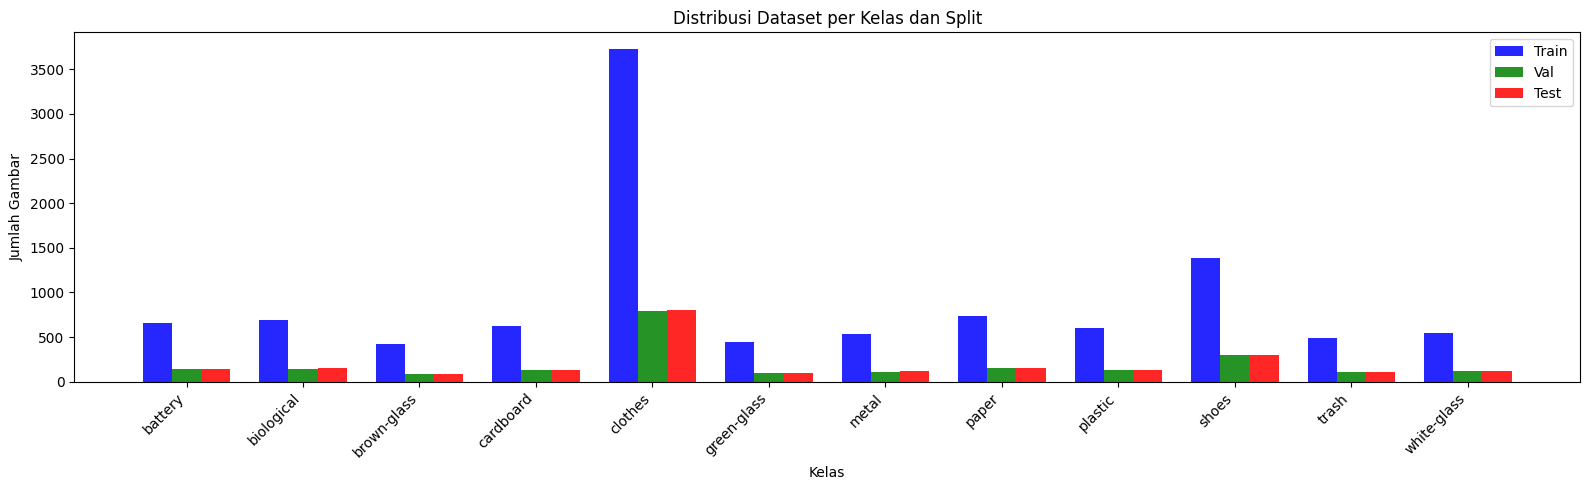

In [7]:
TRAIN_DIR = str(PROCESSED_DATA_DIR / 'train')
VAL_DIR   = str(PROCESSED_DATA_DIR / 'val')
TEST_DIR  = str(PROCESSED_DATA_DIR / 'test')

class_image_counts = {
    class_name: {
        split_name: len(list((PROCESSED_DATA_DIR / split_name / class_name).glob('*')))
        for split_name in SPLIT_NAMES
    }
    for class_name in CLASS_NAMES
    if (PROCESSED_DATA_DIR / 'train' / class_name).exists()
}

fig, ax = plt.subplots(figsize=(16, 5))
x_positions = np.arange(len(CLASS_NAMES))
bar_width   = 0.25
bar_colors  = ['blue', 'green', 'red']

for i, split_name in enumerate(SPLIT_NAMES):
    bar_heights = [class_image_counts[cls][split_name] for cls in CLASS_NAMES]
    ax.bar(x_positions + i * bar_width, bar_heights, bar_width,
           label=split_name.capitalize(), color=bar_colors[i], alpha=0.85)

ax.set_xlabel('Kelas')
ax.set_ylabel('Jumlah Gambar')
ax.set_title('Distribusi Dataset per Kelas dan Split')
ax.set_xticks(x_positions + bar_width)
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

# **PREPROCESSING**

In [8]:
BATCH_SIZE = 32

train_aug = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    shear_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
)
eval_norm = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_aug.flow_from_directory(
    TRAIN_DIR, target_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True, seed=RANDOM_SEED)
val_generator = eval_norm.flow_from_directory(
    VAL_DIR, target_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False)
test_generator = eval_norm.flow_from_directory(
    TEST_DIR, target_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False)

print(f"\nClass indices: {train_generator.class_indices}")

Found 10854 images belonging to 12 classes.
Found 2321 images belonging to 12 classes.
Found 2340 images belonging to 12 classes.

Class indices: {'battery': 0, 'biological': 1, 'brown-glass': 2, 'cardboard': 3, 'clothes': 4, 'green-glass': 5, 'metal': 6, 'paper': 7, 'plastic': 8, 'shoes': 9, 'trash': 10, 'white-glass': 11}


# **MODELING (Two-Phase Fine-Tuning)**

Arsitektur dan strategi pelatihan dibuat **identik dengan notebook 02 (with enhancement)** agar
perbandingan adil. Satu-satunya perbedaan: notebook ini memakai citra **tanpa enhancement**.

In [9]:
def build_model(num_classes, input_shape=(224, 224, 3)):
    base = MobileNetV2(include_top=False, weights='imagenet', input_shape=input_shape)
    base.trainable = False

    inputs = keras.Input(shape=input_shape)
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inputs, outputs, name='mobilenetv2_no_enhancement'), base


model, base_model = build_model(NUM_CLASSES)
model.summary()

2026-06-15 03:17:54.090349: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-06-15 03:17:54.090748: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-06-15 03:17:54.090754: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-06-15 03:17:54.091148: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-06-15 03:17:54.091165: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "mobilenetv2_no_enhancement"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         3,084 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,590,028 (9.88 MB)

 Trainable params: 331,532 (1.26 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

# **TRAINING LOOP: Two-Phase + Class Weight + Label Smoothing**

Sama persis dengan notebook 02: Fase 1 warmup head (base beku), Fase 2 fine-tune sebagian besar
backbone (BatchNorm tetap beku), dengan *class weight* dan *label smoothing* 0.1.

In [10]:
from sklearn.utils.class_weight import compute_class_weight

WARMUP_EPOCHS    = 5
FINE_TUNE_EPOCHS = 40
FINE_TUNE_AT     = 80
HEAD_LR          = 1e-3
FINE_TUNE_LR     = 1e-5
LABEL_SMOOTH     = 0.1

# Disimpan terpisah agar tidak menimpa model versi enhancement
MODEL_DIR       = Path('../../model/mobilenet_no_enhancement')
CHECKPOINT_PATH = str(MODEL_DIR / 'best_model.keras')
HISTORY_PATH    = str(MODEL_DIR / 'training_history.json')
CSV_LOG_PATH    = str(MODEL_DIR / 'training_log.csv')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

y_tr = train_generator.classes
cw = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
class_weight = {i: float(w) for i, w in enumerate(cw)}
print("class_weight:", {k: round(v, 2) for k, v in class_weight.items()})

loss_fn = keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTH)

def make_callbacks():
    return [
        callbacks.EarlyStopping(monitor='val_accuracy', patience=10,
                                restore_best_weights=True, verbose=1),
        callbacks.ModelCheckpoint(CHECKPOINT_PATH, monitor='val_accuracy',
                                  save_best_only=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4,
                                    min_lr=1e-7, verbose=1),
        callbacks.CSVLogger(CSV_LOG_PATH, append=True),
    ]

class_weight: {0: 1.37, 1: 1.31, 2: 2.13, 3: 1.45, 4: 0.24, 5: 2.06, 6: 1.68, 7: 1.23, 8: 1.5, 9: 0.65, 10: 1.86, 11: 1.67}


In [11]:
if os.path.exists(CHECKPOINT_PATH) and os.path.exists(HISTORY_PATH):
    print(f"Checkpoint ditemukan, memuat model dari {CHECKPOINT_PATH}")
    model = tf.keras.models.load_model(CHECKPOINT_PATH)
    with open(HISTORY_PATH) as f:
        history_data = json.load(f)
    print("Model & history dimuat, training dilewati.\n")
else:
    if os.path.exists(CSV_LOG_PATH):
        os.remove(CSV_LOG_PATH)

    print("=" * 50); print("FASE 1: WARMUP HEAD"); print("=" * 50)
    model.compile(optimizer=keras.optimizers.Adam(HEAD_LR), loss=loss_fn, metrics=['accuracy'])
    h1 = model.fit(train_generator, epochs=WARMUP_EPOCHS, validation_data=val_generator,
                   class_weight=class_weight,
                   callbacks=[callbacks.CSVLogger(CSV_LOG_PATH, append=True)], verbose=1)

    print("=" * 50); print("FASE 2: FINE-TUNE"); print("=" * 50)
    base_model.trainable = True
    for layer in base_model.layers[:FINE_TUNE_AT]:
        layer.trainable = False
    for layer in base_model.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False
    trainable = sum(1 for l in base_model.layers if l.trainable)
    print(f"Base trainable layers: {trainable}/{len(base_model.layers)}")

    model.compile(optimizer=keras.optimizers.Adam(FINE_TUNE_LR), loss=loss_fn, metrics=['accuracy'])
    h2 = model.fit(train_generator, epochs=FINE_TUNE_EPOCHS, validation_data=val_generator,
                   class_weight=class_weight, callbacks=make_callbacks(), verbose=1)

    history_data = {k: list(h1.history[k]) + list(h2.history[k])
                    for k in ['accuracy', 'val_accuracy', 'loss', 'val_loss']}
    with open(HISTORY_PATH, 'w') as f:
        json.dump(history_data, f)
    print(f"History disimpan ke {HISTORY_PATH}")

    model = tf.keras.models.load_model(CHECKPOINT_PATH)

num_epochs_trained = len(history_data['accuracy'])
best_val_accuracy  = max(history_data['val_accuracy'])
print(f"\nTotal epoch dilatih : {num_epochs_trained}")
print(f"Best val_accuracy   : {best_val_accuracy:.4f}")

FASE 1: WARMUP HEAD
Epoch 1/5


2026-06-15 03:17:56.829786: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


340/340 ━━━━━━━━━━━━━━━━━━━━ 55s 149ms/step - accuracy: 0.7790 - loss: 1.2981 - val_accuracy: 0.9031 - val_loss: 0.8801
Epoch 2/5
340/340 ━━━━━━━━━━━━━━━━━━━━ 46s 135ms/step - accuracy: 0.8642 - loss: 1.0221 - val_accuracy: 0.9224 - val_loss: 0.8114
Epoch 3/5
340/340 ━━━━━━━━━━━━━━━━━━━━ 48s 142ms/step - accuracy: 0.8822 - loss: 0.9557 - val_accuracy: 0.9289 - val_loss: 0.7948
Epoch 4/5
340/340 ━━━━━━━━━━━━━━━━━━━━ 49s 144ms/step - accuracy: 0.8899 - loss: 0.9343 - val_accuracy: 0.9190 - val_loss: 0.8020
Epoch 5/5
340/340 ━━━━━━━━━━━━━━━━━━━━ 49s 145ms/step - accuracy: 0.8974 - loss: 0.9175 - val_accuracy: 0.9336 - val_loss: 0.7686
FASE 2: FINE-TUNE
Base trainable layers: 49/154
Epoch 1/40
340/340 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.9117 - loss: 0.8759
Epoch 1: val_accuracy improved from None to 0.94227, saving model to ../../model/mobilenet_no_enhancement/best_model.keras

Epoch 1: finished saving model to ../../model/mobilenet_no_enhancement/best_model.keras
340/340 ━━━━

# **EVALUATION**

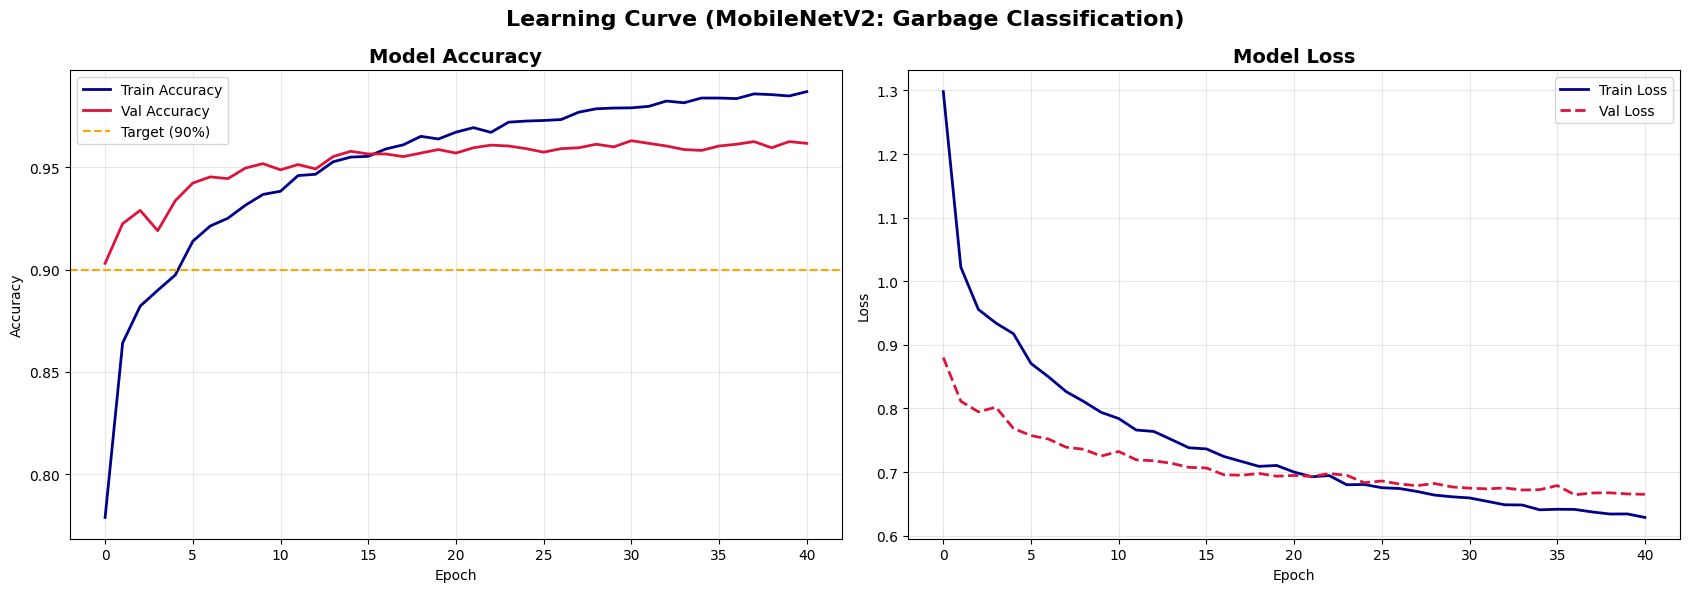

In [12]:
train_accuracy_history = history_data['accuracy']
val_accuracy_history   = history_data['val_accuracy']
train_loss_history     = history_data['loss']
val_loss_history       = history_data['val_loss']

fig, (ax_accuracy, ax_loss) = plt.subplots(1, 2, figsize=(17, 6))

ax_accuracy.plot(train_accuracy_history, label='Train Accuracy', color='darkblue', linewidth=2)
ax_accuracy.plot(val_accuracy_history,   label='Val Accuracy',   color='crimson',  linewidth=2)
ax_accuracy.axhline(y=0.90, color='orange', linestyle='--', linewidth=1.5, label='Target (90%)')
ax_accuracy.set_title('Model Accuracy', fontsize=14, fontweight='bold')
ax_accuracy.set_xlabel('Epoch')
ax_accuracy.set_ylabel('Accuracy')
ax_accuracy.legend()
ax_accuracy.grid(True, alpha=0.3)

ax_loss.plot(train_loss_history, label='Train Loss', color='darkblue', linewidth=2)
ax_loss.plot(val_loss_history,   label='Val Loss',   color='crimson',  linewidth=2, linestyle='--')
ax_loss.set_title('Model Loss', fontsize=14, fontweight='bold')
ax_loss.set_xlabel('Epoch')
ax_loss.set_ylabel('Loss')
ax_loss.legend()
ax_loss.grid(True, alpha=0.3)

plt.suptitle('Learning Curve (MobileNetV2: Garbage Classification)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
train_loss, train_accuracy = model.evaluate(train_generator, verbose=0)
val_loss,   val_accuracy   = model.evaluate(val_generator,   verbose=0)
test_loss,  test_accuracy  = model.evaluate(test_generator,  verbose=0)

print("=" * 50)
print("EVALUASI PADA TEST SET")
print("=" * 50)
print(f"Train Accuracy : {train_accuracy * 100:.2f}%")
print(f"Val   Accuracy : {val_accuracy   * 100:.2f}%")
print(f"Test  Accuracy : {test_accuracy  * 100:.2f}%")
print()
print(f"Train Loss     : {train_loss:.4f}")
print(f"Val   Loss     : {val_loss:.4f}")
print(f"Test  Loss     : {test_loss:.4f}")

EVALUASI PADA TEST SET
Train Accuracy : 98.80%
Val   Accuracy : 96.29%
Test  Accuracy : 96.24%

Train Loss     : 0.6086
Val   Loss     : 0.6748
Test  Loss     : 0.6740


In [14]:
test_generator.reset()

predicted_probabilities = model.predict(test_generator, verbose=1)
predicted_labels        = np.argmax(predicted_probabilities, axis=1)
true_labels             = test_generator.classes
class_labels            = list(test_generator.class_indices.keys())

print("\nClassification Report:")
print(classification_report(true_labels, predicted_labels, target_names=class_labels))

74/74 ━━━━━━━━━━━━━━━━━━━━ 10s 110ms/step

Classification Report:
              precision    recall  f1-score   support

     battery       0.99      0.97      0.98       143
  biological       0.99      0.98      0.98       149
 brown-glass       0.95      0.97      0.96        92
   cardboard       0.97      0.96      0.97       135
     clothes       1.00      0.99      0.99       800
 green-glass       0.92      0.97      0.94        95
       metal       0.88      0.97      0.92       116
       paper       0.93      0.96      0.95       158
     plastic       0.93      0.76      0.84       131
       shoes       0.96      0.98      0.97       298
       trash       0.97      0.97      0.97       106
 white-glass       0.86      0.91      0.89       117

    accuracy                           0.96      2340
   macro avg       0.94      0.95      0.95      2340
weighted avg       0.96      0.96      0.96      2340



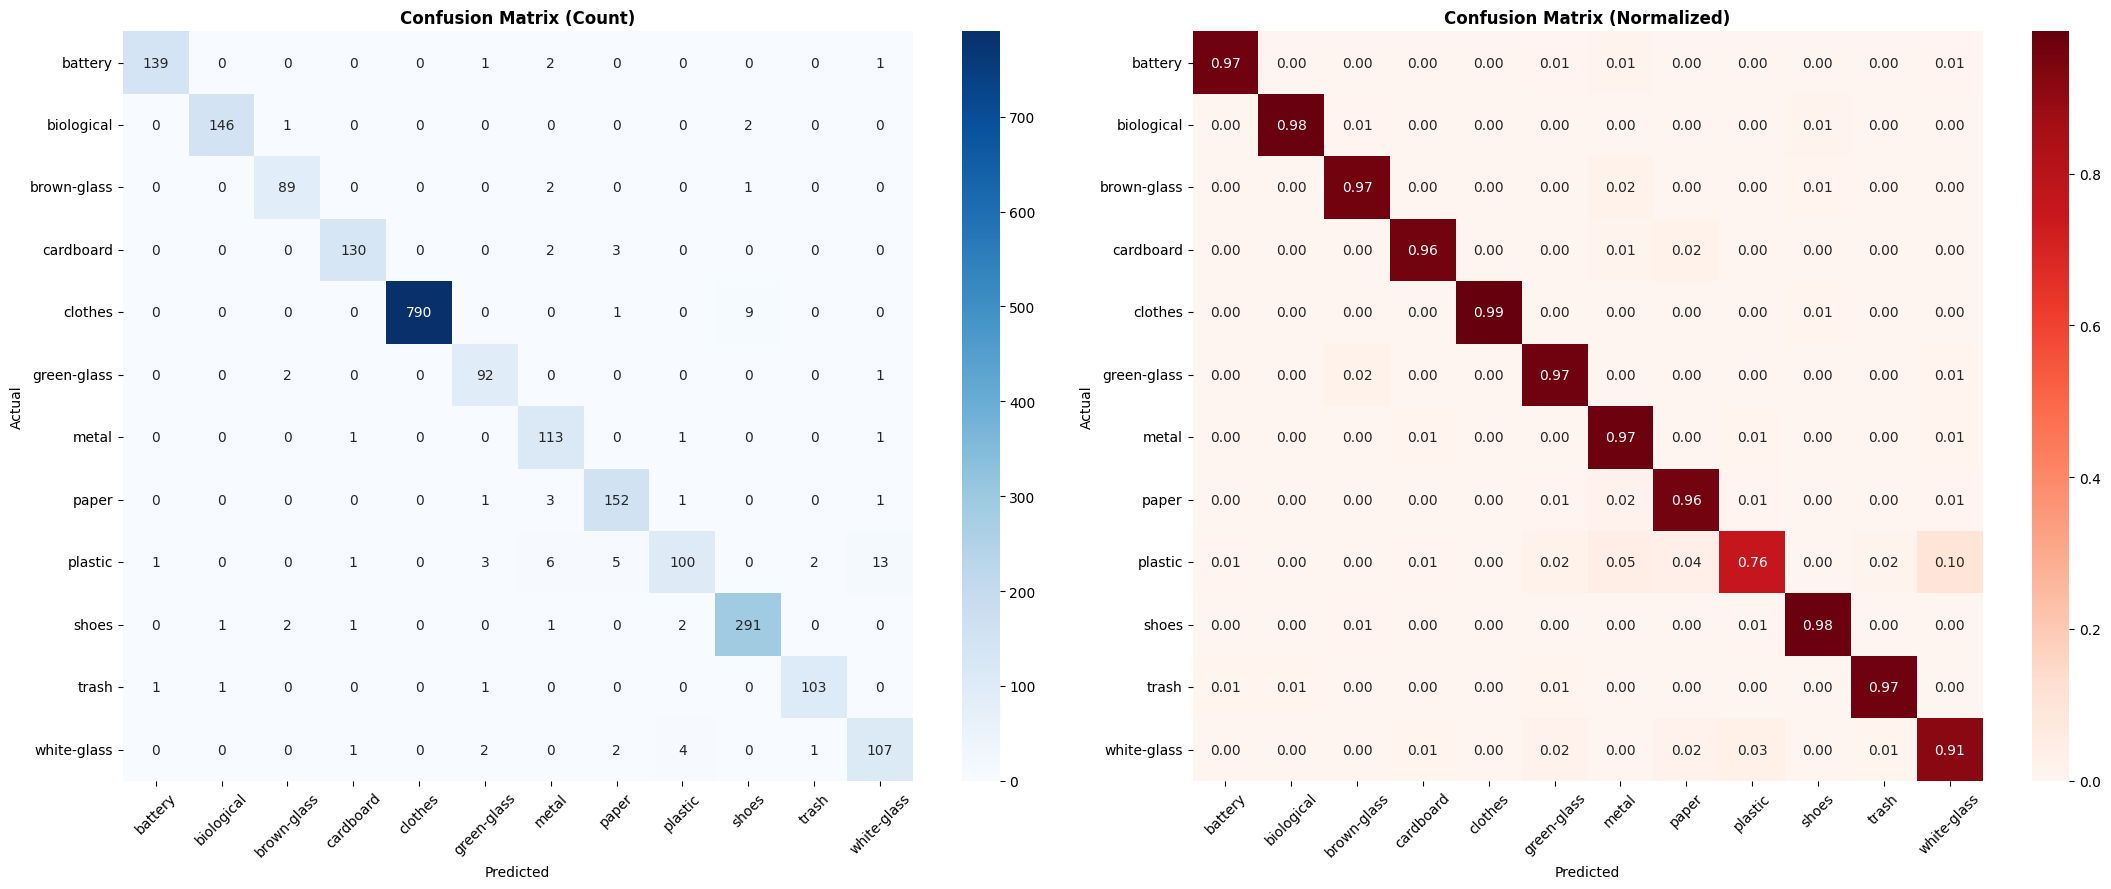

In [15]:
conf_matrix            = confusion_matrix(true_labels, predicted_labels)
conf_matrix_normalized = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

fig, (ax_count, ax_normalized) = plt.subplots(1, 2, figsize=(22, 9))

sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels, ax=ax_count)
ax_count.set_title('Confusion Matrix (Count)', fontweight='bold')
ax_count.set_xlabel('Predicted')
ax_count.set_ylabel('Actual')
ax_count.tick_params(axis='x', rotation=45)

sns.heatmap(conf_matrix_normalized, annot=True, fmt='.2f', cmap='Reds',
            xticklabels=class_labels, yticklabels=class_labels, ax=ax_normalized)
ax_normalized.set_title('Confusion Matrix (Normalized)', fontweight='bold')
ax_normalized.set_xlabel('Predicted')
ax_normalized.set_ylabel('Actual')
ax_normalized.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# **INFERENCE**

Model loaded from ../../model/mobilenet_no_enhancement/best_model.keras


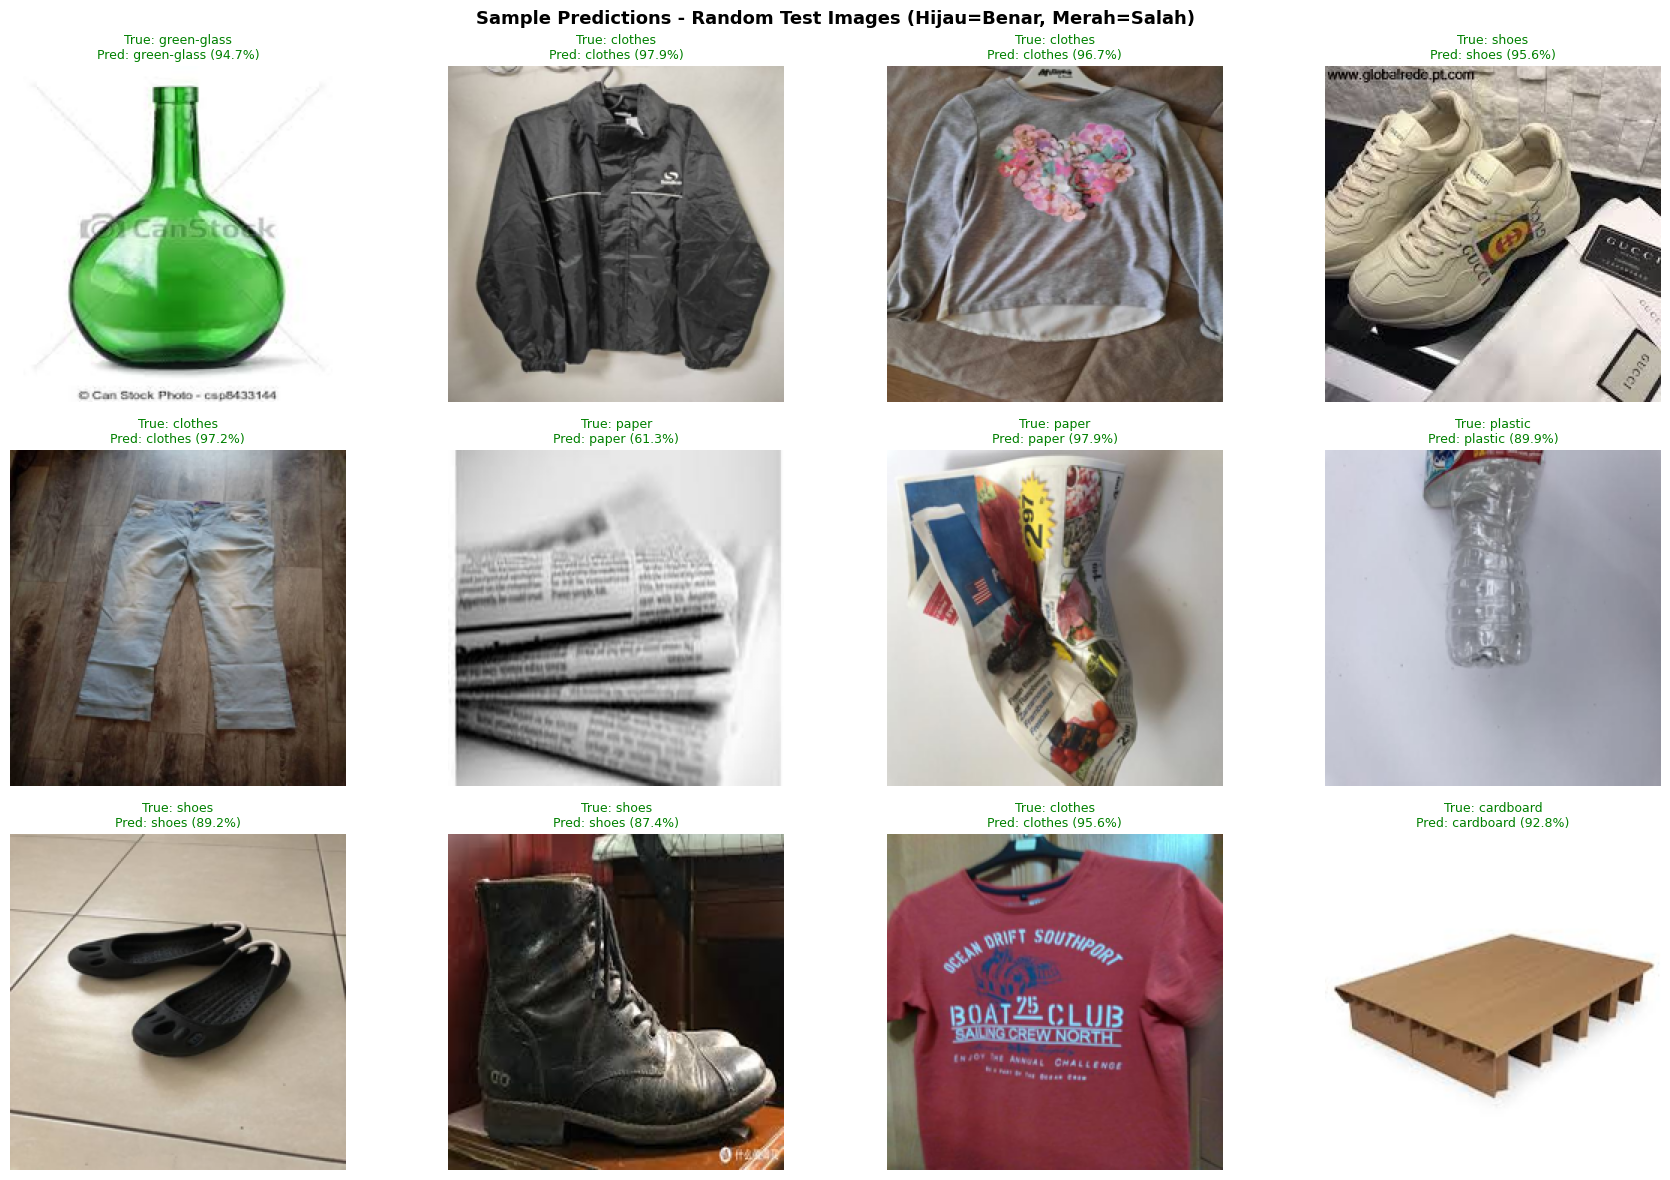

In [16]:
CHECKPOINT_PATH     = '../../model/mobilenet_no_enhancement/best_model.keras'
NUM_SAMPLE_PREDICTIONS = 12

inference_model = tf.keras.models.load_model(CHECKPOINT_PATH)
print(f'Model loaded from {CHECKPOINT_PATH}')

# Collect all test images across all classes
test_data_dir = Path(TEST_DIR)
all_test_images = []
for class_folder in sorted(test_data_dir.iterdir()):
    if class_folder.is_dir():
        for img_path in class_folder.glob('*'):
            if img_path.suffix.lower() in ('.jpg', '.jpeg', '.png'):
                all_test_images.append((img_path, class_folder.name))

random.shuffle(all_test_images)
sampled = all_test_images[:NUM_SAMPLE_PREDICTIONS]

sample_images_raw = []
sample_true_labels = []
for img_path, class_name in sampled:
    img = Image.open(img_path).convert('RGB').resize(IMAGE_SIZE)
    img_array = np.array(img, dtype=np.float32)
    sample_images_raw.append(img_array)
    sample_true_labels.append(class_name)

sample_images_input = preprocess_input(np.array(sample_images_raw))
sample_predicted_probs = inference_model.predict(sample_images_input, verbose=0)

cols = 4
rows = (NUM_SAMPLE_PREDICTIONS + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4))
axes = axes.flatten()

for i in range(NUM_SAMPLE_PREDICTIONS):
    true_label      = sample_true_labels[i]
    predicted_label = class_labels[np.argmax(sample_predicted_probs[i])]
    confidence_pct  = np.max(sample_predicted_probs[i]) * 100
    is_correct      = true_label == predicted_label

    display_img = np.clip(sample_images_raw[i] / 255.0, 0, 1)

    axes[i].imshow(display_img)
    axes[i].set_title(
        f'True: {true_label}\nPred: {predicted_label} ({confidence_pct:.1f}%)',
        color='green' if is_correct else 'red',
        fontsize=9,
    )
    axes[i].axis('off')

for i in range(NUM_SAMPLE_PREDICTIONS, len(axes)):
    axes[i].axis('off')

plt.suptitle('Sample Predictions - Random Test Images (Hijau=Benar, Merah=Salah)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
